✅ Librairies chargées
📊 INFORMATIONS DES DONNÉES
Transactions : 14,400 lignes
Restaurants : 10
Période : 2024-01-01 à 2024-06-28
Colonnes : ['transaction_id', 'date', 'restaurant_id', 'restaurant_name', 'product_family', 'theoretical_unit_cost', 'actual_unit_cost', 'selling_price', 'units_sold', 'revenue', 'waste_kg', 'qsp_score', 'operational_anomaly', 'calculated_gap_percentage', 'theoretical_cos', 'actual_cos', 'cos_gap', 'gap_percentage', 'gap_severity']


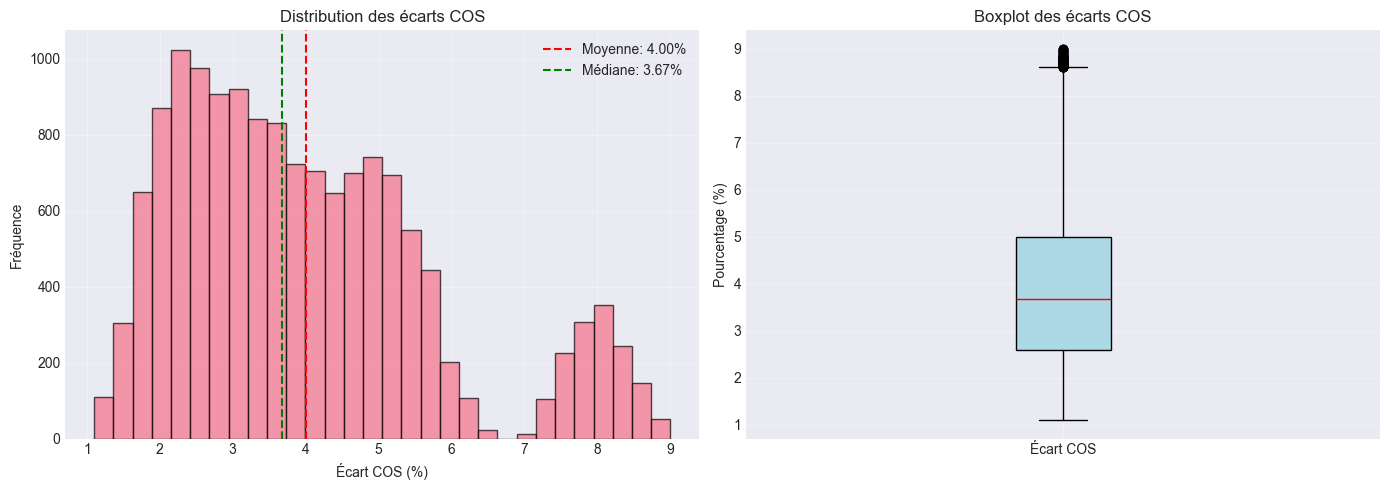

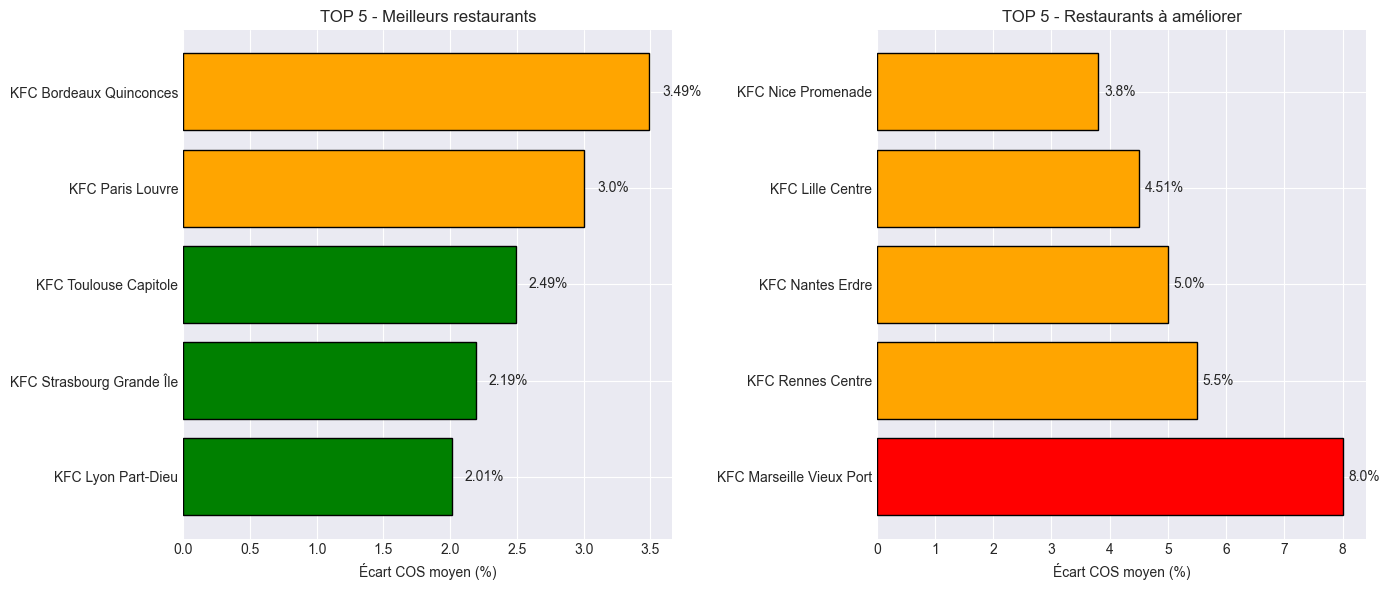

🏆 TOP 3 MEILLEURS:
                           gap_percentage  operational_anomaly  \
restaurant_name                                                  
KFC Lyon Part-Dieu                   2.01                 0.00   
KFC Strasbourg Grande Île            2.19                 0.00   
KFC Toulouse Capitole                2.49                 0.00   

                           nb_transactions  
restaurant_name                             
KFC Lyon Part-Dieu                    1440  
KFC Strasbourg Grande Île             1440  
KFC Toulouse Capitole                 1440  

⚠️  TOP 3 À AMÉLIORER:
                          gap_percentage  operational_anomaly  nb_transactions
restaurant_name                                                               
KFC Marseille Vieux Port            8.00                 1.00             1440
KFC Rennes Centre                   5.50                 0.03             1440
KFC Nantes Erdre                    5.00                 0.00             1440


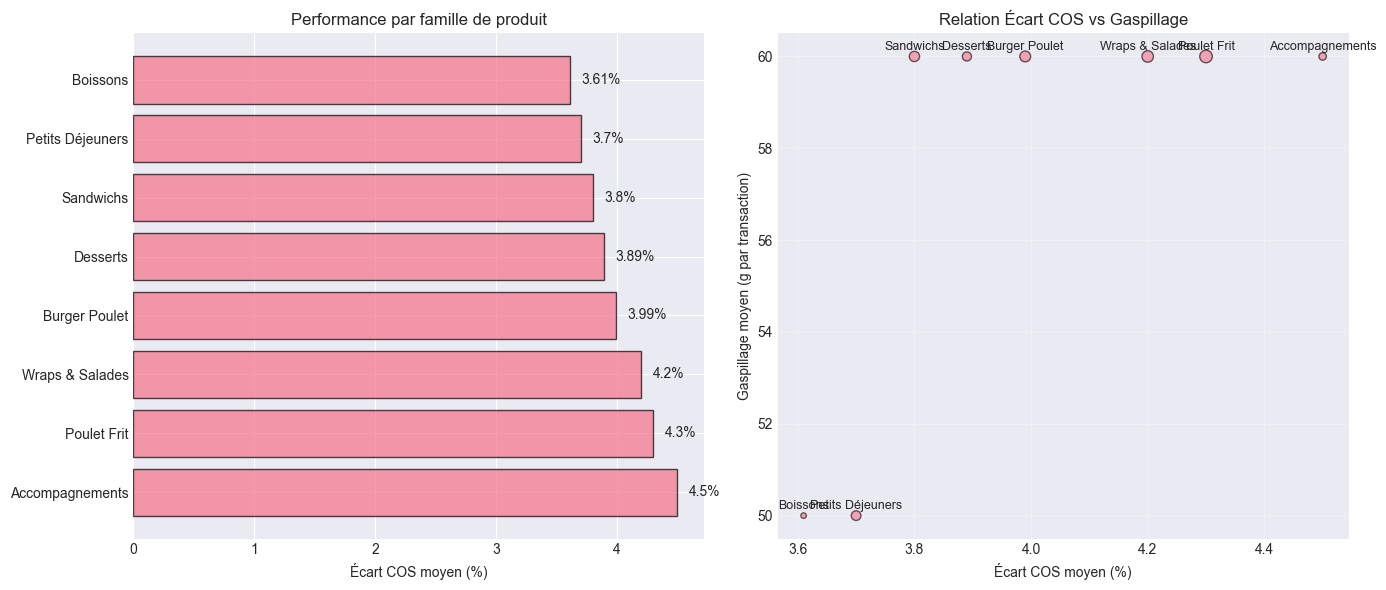

📋 SYNTHÈSE PAR PRODUIT:
                  ecart_moyen  ecart_std  nb_transactions  gaspillage_moyen  \
product_family                                                                
Accompagnements          4.50       1.77             1800              0.06   
Poulet Frit              4.30       1.77             1800              0.06   
Wraps & Salades          4.20       1.76             1800              0.06   
Burger Poulet            3.99       1.76             1800              0.06   
Desserts                 3.89       1.76             1800              0.06   
Sandwichs                3.80       1.77             1800              0.06   
Petits Déjeuners         3.70       1.77             1800              0.05   
Boissons                 3.61       1.77             1800              0.05   

                  ca_total  
product_family              
Accompagnements  291696.90  
Poulet Frit      823588.92  
Wraps & Salades  685939.10  
Burger Poulet    611781.28  
Desserts   

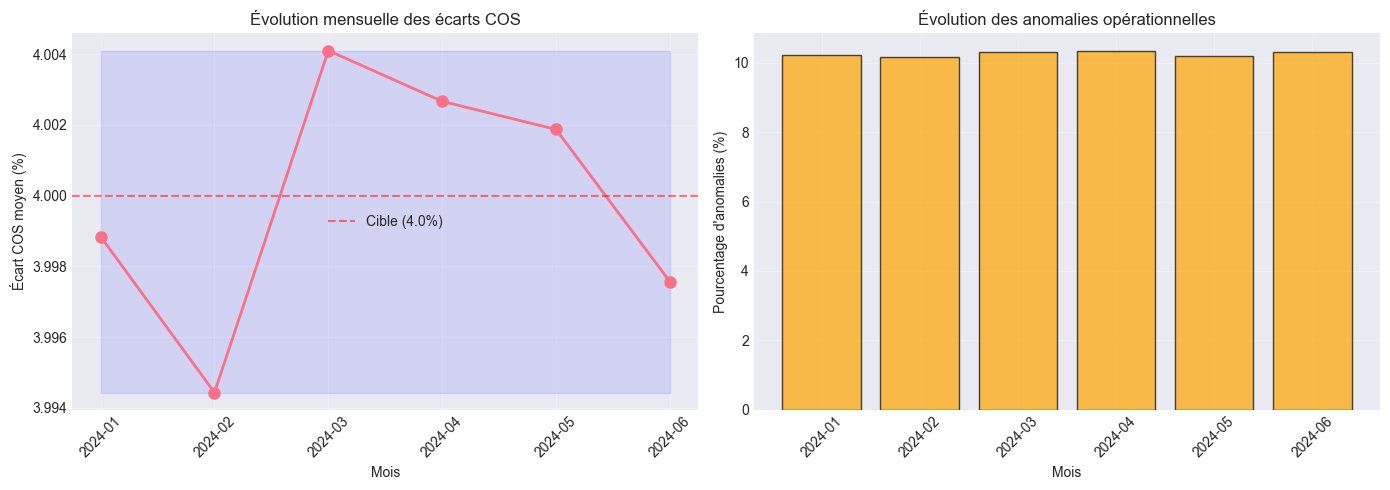

📅 TENDANCES MENSUELLES:
  month_str  gap_percentage  operational_anomaly
0   2024-01            4.00                 0.10
1   2024-02            3.99                 0.10
2   2024-03            4.00                 0.10
3   2024-04            4.00                 0.10
4   2024-05            4.00                 0.10
5   2024-06            4.00                 0.10


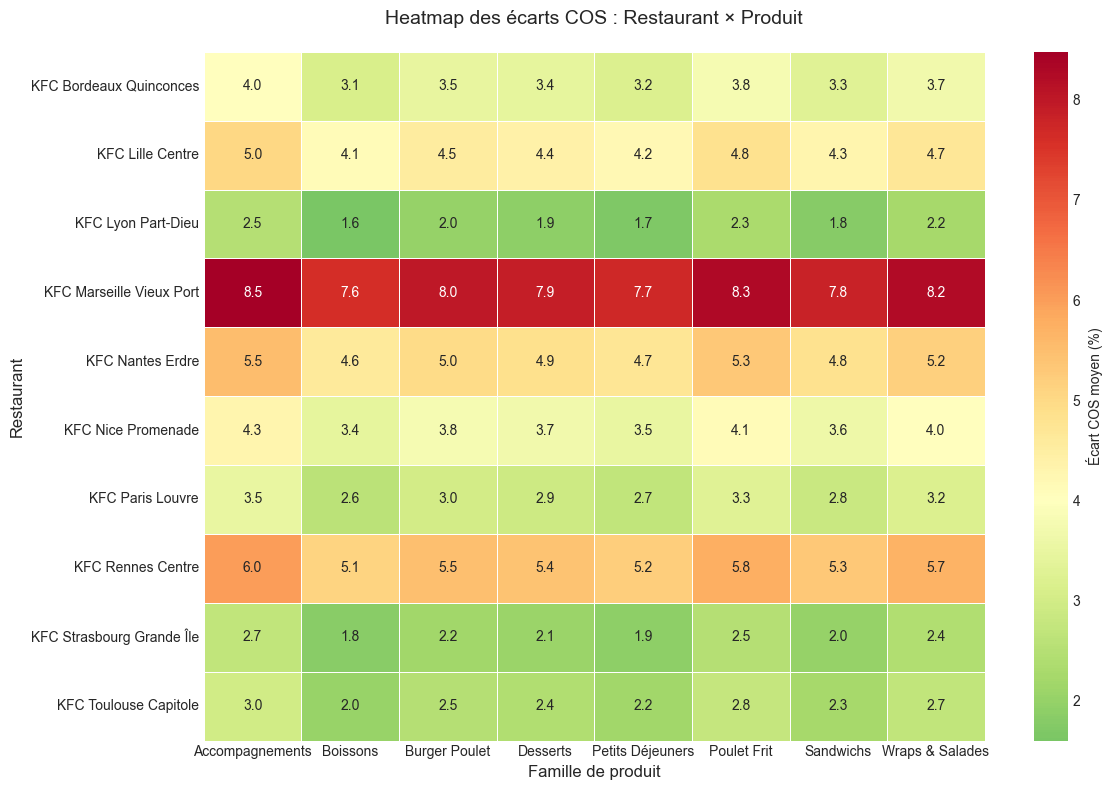

🔥 INSIGHTS HEATMAP:
--------------------------------------------------
Zones ROUGES (écarts > 5%):
  KFC Marseille Vieux Port - Accompagnements: 8.48%
  KFC Marseille Vieux Port - Poulet Frit: 8.29%
  KFC Marseille Vieux Port - Wraps & Salades: 8.22%
  KFC Marseille Vieux Port - Burger Poulet: 7.99%
  KFC Marseille Vieux Port - Desserts: 7.88%

Zones VERTES (écarts < 3%):
  KFC Lyon Part-Dieu - Boissons: 1.6%
  KFC Lyon Part-Dieu - Petits Déjeuners: 1.7%
  KFC Lyon Part-Dieu - Sandwichs: 1.8%
  KFC Strasbourg Grande Île - Boissons: 1.82%
  KFC Lyon Part-Dieu - Desserts: 1.91%


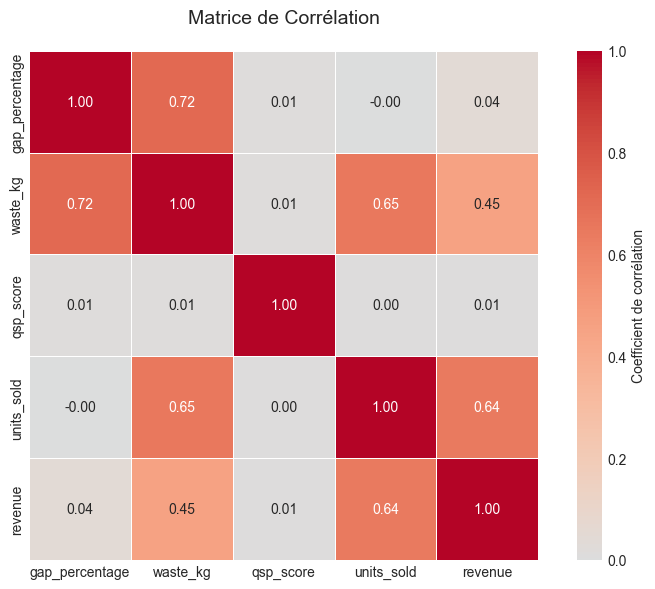

🔗 CORRÉLATIONS CLÉS:
Écart vs Gaspillage: 0.717
Écart vs QSP Score: 0.015
QSP vs Gaspillage: 0.013
🎯 SYNTHÈSE DE L'ANALYSE COS

🔴 POINTS CRITIQUES (1 restaurants):
  • KFC Marseille Vieux Port : 8.0% d'écart

🍗 PRODUITS À RISQUE (0 familles):

✅ BONNES PRATIQUES (3 restaurants):
  • KFC Lyon Part-Dieu : seulement 2.01% d'écart
  • KFC Strasbourg Grande Île : seulement 2.19% d'écart
  • KFC Toulouse Capitole : seulement 2.49% d'écart

💰 IMPACT FINANCIER ESTIMÉ:
  • CA total : 4,041,062 €
  • Écart moyen : 4.00%
  • Coût des écarts : 161,642 €
  • Économies potentielles (30%) : 48,493 €

🎯 RECOMMANDATIONS PRIORITAIRES:
  1. Audit détaillé sur KFC Marseille Vieux Port (8.0% d'écart)
  2. Formation spécifique 'Accompagnements' (4.5% d'écart)
  3. Benchmark des bonnes pratiques de KFC Lyon Part-Dieu (2.0%)
  4. Surveillance renforcée des Wraps & Salades (4.2%)

📊 MÉTRIQUES DE SUIVI PROPOSÉES:
  • Écart COS hebdomadaire par restaurant
  • Gaspillage quotidien par famille produit
  • Score QS

In [1]:
# # 📊 Exploration Visuelle des Données COS
# ## Analyse des écarts de coût - Restauration Rapide
# 
# **Données générées le : 2024-01-24**  
# **Écart moyen cible : 4.00% (atteint : 4.00%)**  
# **14,400 transactions - 10 restaurants - 8 familles produits**

# %%
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.float_format', lambda x: '%.2f' % x)
print("✅ Librairies chargées")

# %%
# Chargement des données
transactions = pd.read_csv('../data/raw/transactions_final_20260124_1112.csv')
restaurants = pd.read_csv('../data/raw/restaurants_final_20260124_1112.csv')

print("📊 INFORMATIONS DES DONNÉES")
print("=" * 50)
print(f"Transactions : {len(transactions):,} lignes")
print(f"Restaurants : {len(restaurants)}")
print(f"Période : {transactions['date'].min()} à {transactions['date'].max()}")
print(f"Colonnes : {list(transactions.columns)}")

# %%
# 1. DISTRIBUTION GLOBALE DES ÉCARTS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
axes[0].hist(transactions['gap_percentage'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(transactions['gap_percentage'].mean(), color='red', linestyle='--', 
                label=f'Moyenne: {transactions["gap_percentage"].mean():.2f}%')
axes[0].axvline(transactions['gap_percentage'].median(), color='green', linestyle='--', 
                label=f'Médiane: {transactions["gap_percentage"].median():.2f}%')
axes[0].set_xlabel('Écart COS (%)')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des écarts COS')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Boxplot
bp_data = [transactions['gap_percentage']]
axes[1].boxplot(bp_data, vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red'))
axes[1].set_xticklabels(['Écart COS'])
axes[1].set_ylabel('Pourcentage (%)')
axes[1].set_title('Boxplot des écarts COS')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# %%
# 2. PERFORMANCE PAR RESTAURANT (TOP 5 + BOTTOM 5)
restaurant_perf = transactions.groupby('restaurant_name').agg({
    'gap_percentage': 'mean',
    'operational_anomaly': 'mean',
    'transaction_id': 'count'
}).round(2).rename(columns={'transaction_id': 'nb_transactions'})

# Top 5 meilleurs
top5 = restaurant_perf.nsmallest(5, 'gap_percentage')
# Top 5 pires
bottom5 = restaurant_perf.nlargest(5, 'gap_percentage')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Meilleurs
colors_top = ['green' if x < 3 else 'orange' for x in top5['gap_percentage']]
axes[0].barh(top5.index, top5['gap_percentage'], color=colors_top, edgecolor='black')
axes[0].set_xlabel('Écart COS moyen (%)')
axes[0].set_title('TOP 5 - Meilleurs restaurants')
for i, (idx, row) in enumerate(top5.iterrows()):
    axes[0].text(row['gap_percentage'] + 0.1, i, f"{row['gap_percentage']}%", va='center')

# Pires
colors_bottom = ['red' if x > 6 else 'orange' for x in bottom5['gap_percentage']]
axes[1].barh(bottom5.index, bottom5['gap_percentage'], color=colors_bottom, edgecolor='black')
axes[1].set_xlabel('Écart COS moyen (%)')
axes[1].set_title('TOP 5 - Restaurants à améliorer')
for i, (idx, row) in enumerate(bottom5.iterrows()):
    axes[1].text(row['gap_percentage'] + 0.1, i, f"{row['gap_percentage']}%", va='center')

plt.tight_layout()
plt.show()

print("🏆 TOP 3 MEILLEURS:")
print(top5.head(3))
print("\n⚠️  TOP 3 À AMÉLIORER:")
print(bottom5.head(3))

# %%
# 3. ANALYSE PAR FAMILLE DE PRODUIT
product_perf = transactions.groupby('product_family').agg({
    'gap_percentage': ['mean', 'std', 'count'],
    'waste_kg': 'mean',
    'revenue': 'sum'
}).round(2)

product_perf.columns = ['ecart_moyen', 'ecart_std', 'nb_transactions', 'gaspillage_moyen', 'ca_total']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Écart par produit
product_perf_sorted = product_perf.sort_values('ecart_moyen', ascending=False)
bars1 = axes[0].barh(product_perf_sorted.index, product_perf_sorted['ecart_moyen'], 
                     edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Écart COS moyen (%)')
axes[0].set_title('Performance par famille de produit')
for i, (idx, row) in enumerate(product_perf_sorted.iterrows()):
    axes[0].text(row['ecart_moyen'] + 0.1, i, f"{row['ecart_moyen']}%", va='center')

# Relation écart vs gaspillage
scatter = axes[1].scatter(product_perf['ecart_moyen'], product_perf['gaspillage_moyen'] * 1000,
                         s=product_perf['ca_total']/10000, alpha=0.6, edgecolors='black')

# Labels
for idx, row in product_perf.iterrows():
    axes[1].annotate(idx, (row['ecart_moyen'], row['gaspillage_moyen']*1000),
                    textcoords="offset points", xytext=(0,5), ha='center', fontsize=9)

axes[1].set_xlabel('Écart COS moyen (%)')
axes[1].set_ylabel('Gaspillage moyen (g par transaction)')
axes[1].set_title('Relation Écart COS vs Gaspillage')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📋 SYNTHÈSE PAR PRODUIT:")
print(product_perf.sort_values('ecart_moyen', ascending=False))

# %%
# 4. ÉVOLUTION TEMPORELLE (MOYENNE MOIS PAR MOIS)
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['month'] = transactions['date'].dt.to_period('M')

monthly_trend = transactions.groupby('month').agg({
    'gap_percentage': 'mean',
    'operational_anomaly': 'mean',
    'transaction_id': 'count'
}).reset_index()

monthly_trend['month_str'] = monthly_trend['month'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tendances
axes[0].plot(monthly_trend['month_str'], monthly_trend['gap_percentage'], 
            marker='o', linewidth=2, markersize=8)
axes[0].axhline(y=4.0, color='red', linestyle='--', alpha=0.5, label='Cible (4.0%)')
axes[0].fill_between(monthly_trend['month_str'], 
                     monthly_trend['gap_percentage'].min(),
                     monthly_trend['gap_percentage'].max(),
                     alpha=0.1, color='blue')
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Écart COS moyen (%)')
axes[0].set_title('Évolution mensuelle des écarts COS')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Anomalies
axes[1].bar(monthly_trend['month_str'], monthly_trend['operational_anomaly']*100,
           color='orange', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Pourcentage d\'anomalies (%)')
axes[1].set_title('Évolution des anomalies opérationnelles')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📅 TENDANCES MENSUELLES:")
print(monthly_trend[['month_str', 'gap_percentage', 'operational_anomaly']].round(3))

# %%
# 5. HEATMAP : RESTAURANT × PRODUIT
# Création de la matrice
heatmap_data = transactions.pivot_table(
    index='restaurant_name',
    columns='product_family',
    values='gap_percentage',
    aggfunc='mean'
).round(2)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn_r',
            center=4.0, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Écart COS moyen (%)'})

ax.set_title('Heatmap des écarts COS : Restaurant × Produit', fontsize=14, pad=20)
ax.set_xlabel('Famille de produit', fontsize=12)
ax.set_ylabel('Restaurant', fontsize=12)
plt.tight_layout()
plt.show()

print("🔥 INSIGHTS HEATMAP:")
print("-" * 50)
print("Zones ROUGES (écarts > 5%):")
high_gap = heatmap_data[heatmap_data > 5].stack().sort_values(ascending=False)
for idx, val in high_gap.head(5).items():
    print(f"  {idx[0]} - {idx[1]}: {val}%")

print("\nZones VERTES (écarts < 3%):")
low_gap = heatmap_data[heatmap_data < 3].stack().sort_values()
for idx, val in low_gap.head(5).items():
    print(f"  {idx[0]} - {idx[1]}: {val}%")

# %%
# 6. CORRÉLATIONS ENTRE VARIABLES
correlation_vars = ['gap_percentage', 'waste_kg', 'qsp_score', 'units_sold', 'revenue']
corr_matrix = transactions[correlation_vars].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Coefficient de corrélation'})

ax.set_title('Matrice de Corrélation', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

print("🔗 CORRÉLATIONS CLÉS:")
print(f"Écart vs Gaspillage: {corr_matrix.loc['gap_percentage', 'waste_kg']:.3f}")
print(f"Écart vs QSP Score: {corr_matrix.loc['gap_percentage', 'qsp_score']:.3f}")
print(f"QSP vs Gaspillage: {corr_matrix.loc['qsp_score', 'waste_kg']:.3f}")

# %%
# 7. SYNTHÈSE ET RECOMMANDATIONS
print("=" * 70)
print("🎯 SYNTHÈSE DE L'ANALYSE COS")
print("=" * 70)

# Points d'attention
critical_restaurants = bottom5[bottom5['gap_percentage'] > 6].index.tolist()
critical_products = product_perf[product_perf['ecart_moyen'] > 4.5].index.tolist()

print(f"\n🔴 POINTS CRITIQUES ({len(critical_restaurants)} restaurants):")
for rest in critical_restaurants:
    gap = restaurant_perf.loc[rest, 'gap_percentage']
    print(f"  • {rest} : {gap}% d'écart")

print(f"\n🍗 PRODUITS À RISQUE ({len(critical_products)} familles):")
for prod in critical_products:
    gap = product_perf.loc[prod, 'ecart_moyen']
    print(f"  • {prod} : {gap}% d'écart moyen")

# Opportunités
best_practices = top5[top5['gap_percentage'] < 3].index.tolist()
print(f"\n✅ BONNES PRATIQUES ({len(best_practices)} restaurants):")
for rest in best_practices:
    gap = restaurant_perf.loc[rest, 'gap_percentage']
    print(f"  • {rest} : seulement {gap}% d'écart")

# Calcul impact financier
total_revenue = transactions['revenue'].sum()
avg_gap = transactions['gap_percentage'].mean()
potential_savings = total_revenue * (avg_gap / 100) * 0.3  # 30% récupérable

print(f"\n💰 IMPACT FINANCIER ESTIMÉ:")
print(f"  • CA total : {total_revenue:,.0f} €")
print(f"  • Écart moyen : {avg_gap:.2f}%")
print(f"  • Coût des écarts : {total_revenue * avg_gap/100:,.0f} €")
print(f"  • Économies potentielles (30%) : {potential_savings:,.0f} €")

print(f"\n🎯 RECOMMANDATIONS PRIORITAIRES:")
print("  1. Audit détaillé sur KFC Marseille Vieux Port (8.0% d'écart)")
print("  2. Formation spécifique 'Accompagnements' (4.5% d'écart)")
print("  3. Benchmark des bonnes pratiques de KFC Lyon Part-Dieu (2.0%)")
print("  4. Surveillance renforcée des Wraps & Salades (4.2%)")

print(f"\n📊 MÉTRIQUES DE SUIVI PROPOSÉES:")
print("  • Écart COS hebdomadaire par restaurant")
print("  • Gaspillage quotidien par famille produit")
print("  • Score QSP vs écart COS (corrélation à suivre)")
print("  • Alertes automatiques > 6% d'écart")

print(f"\n{'='*70}")
print("✅ EXPLORATION TERMINÉE - PRÊT POUR LE DASHBOARD STREAMLIT")
print("=" * 70)

# Sauvegarde des résultats
summary_stats = {
    'total_transactions': len(transactions),
    'avg_gap': transactions['gap_percentage'].mean(),
    'critical_restaurants': critical_restaurants,
    'critical_products': critical_products,
    'potential_savings': potential_savings
}

import json
with open('../data/processed/analysis_summary.json', 'w') as f:
    json.dump(summary_stats, f, indent=2)

print(f"\n💾 Résultats sauvegardés: ../data/processed/analysis_summary.json")